In [12]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 (D+003 버전)
# - 어제 발견한 오염을 그대로 가져오되, 결측/이상치를 더 다양하게 심습니다.
# - 이 셀 하나로 오늘 쓸 데이터가 전부 준비됩니다 (이 노트북은 단독 실행 가능).
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers)
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
    "income": np.random.choice([2500, 3500, 4500, 6000, 8500], n_customers).astype(float),
})

# 오염 심기 — 나이 이상치
customers.loc[5, "age"] = 999            # 입력 실수로 보이는 이상치
customers.loc[10, "age"] = -3            # 음수 나이(불가능한 값)
customers.loc[15, "age"] = 120           # 매우 큰 값 (이상치 후보)

# 오염 심기 — 성별 결측 (관찰자가 응답을 안 받았을 가능성: MCAR에 가까움)
customers.loc[[20, 21, 22, 70, 120], "gender"] = np.nan

# 오염 심기 — 소득 결측 (고소득 고객일수록 응답 거절 → MNAR 신호)
high_income_mask = customers["income"] >= 6000
high_idx = customers[high_income_mask].sample(frac=0.4, random_state=1).index
customers.loc[high_idx, "income"] = np.nan

# 2) 상품(products)
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders)
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "category": products.set_index("product_id").loc[order_product, "category"].values,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
})

# 오염 심기 — 금액 결측 (일부 채널에서만 결측이 더 잦음 → MAR 신호)
app_mask = orders["channel"] == "app"
app_idx = orders[app_mask].sample(frac=0.04, random_state=2).index
web_idx = orders[~app_mask].sample(frac=0.01, random_state=3).index
orders.loc[app_idx.union(web_idx), "amount"] = np.nan

# 오염 심기 — 수량 이상치
orders.loc[7, "quantity"] = 100         # 비정상적으로 큰 주문 수량
orders.loc[1900, "quantity"] = 50       # 또 하나의 극단값
orders.loc[1500, "amount"] = 5_000_000  # 금액 자체의 극단값

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)
print("\n[빠르게 둘러보기]")
print("customers 결측:", customers.isnull().sum().sum(), "건")
print("orders 결측:", orders.isnull().sum().sum(), "건")

모두마켓 데이터 생성 완료
customers: (300, 6) | products: (40, 3) | orders: (2000, 7)

[빠르게 둘러보기]
customers 결측: 51 건
orders 결측: 51 건


In [3]:
# 새 데이터셋 — '옷장패션' 주문 (가상)
import numpy as np 
import pandas as pd

np.random.seed(11)
n = 1500

partner = pd.DataFrame({
    "order_id": [f"K{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(33, 8, n).round().astype(int),
    "category": np.random.choice(["상의", "하의", "신발", "액세서리"], n, p=[0.35, 0.3, 0.2, 0.15]),
    "channel": np.random.choice(["web", "app"], n, p=[0.4, 0.6]),
    "price": np.random.choice([15900, 29900, 49900, 79900, 129900], n),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n),
})
partner["amount"] = partner["price"] * partner["quantity"]
partner["return_amount"] = np.where(
    np.random.rand(n) < 0.07, partner["amount"] * np.random.uniform(0.5, 1.0, n), 0
).round(0)

# 오염 심기
# (a) 나이 이상치 — 입력 실수(0, 999)
partner.loc[partner.sample(3, random_state=1).index, "customer_age"] = 999
partner.loc[partner.sample(2, random_state=2).index, "customer_age"] = 0

# (b) amount 결측 — app 채널에 더 자주 (MAR 시그널)
app = partner["channel"] == "app"
partner.loc[partner[app].sample(frac=0.05, random_state=3).index, "amount"] = np.nan
partner.loc[partner[~app].sample(frac=0.01, random_state=4).index, "amount"] = np.nan

# (c) return_amount 결측은 그대로 (0=환불없음)이라 결측 아님. 단, '관찰 안 됨'을 의도적으로 표현하기 위해
#     price 결측 5건 추가(접속 시점 가격이 누락된 사례)
partner.loc[partner.sample(5, random_state=5).index, "price"] = np.nan

# (d) quantity 이상치(단일 소비자 200개)
partner.loc[partner.sample(1, random_state=6).index, "quantity"] = 200

# (e) amount 극단값(50,000,000짜리 한 건 — '도매 의심')
partner.loc[partner.sample(1, random_state=7).index, "amount"] = 50_000_000

print("옷장패션 데이터 준비 완료:", partner.shape)
partner.head()

옷장패션 데이터 준비 완료: (1500, 8)


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
0,K00001,47,신발,app,29900.0,2,59800.0,45445.0
1,K00002,31,상의,app,129900.0,3,389700.0,0.0
2,K00003,29,상의,web,49900.0,2,99800.0,0.0
3,K00004,12,상의,web,49900.0,3,149700.0,0.0
4,K00005,33,하의,app,129900.0,1,129900.0,0.0


In [4]:
# 시나리오 1 — 진단
print("shape:", partner.shape)
partner.info()
display(partner.describe())

shape: (1500, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   str    
 1   customer_age   1500 non-null   int64  
 2   category       1500 non-null   str    
 3   channel        1500 non-null   str    
 4   price          1495 non-null   float64
 5   quantity       1500 non-null   int64  
 6   amount         1449 non-null   float64
 7   return_amount  1500 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 93.9 KB


,customer_age,price,quantity,amount,return_amount
count,1500.000000,1495.000000,1500.000000,1.449000e+03,1500.000000
mean,34.903333,60960.869565,1.789333,1.350475e+05,6381.010000
std,43.936525,40275.103681,5.173406,1.313695e+06,28315.037316
min,0.000000,15900.000000,1.000000,1.590000e+04,0.000000
25%,28.000000,29900.000000,1.000000,4.770000e+04,0.000000
50%,33.000000,49900.000000,2.000000,7.990000e+04,0.000000
75%,38.250000,79900.000000,2.000000,1.299000e+05,0.000000
max,999.000000,129900.000000,200.000000,5.000000e+07,322778.000000


In [5]:
def missing_summary(df):
    s = df.isnull().sum()
    p = (df.isnull().mean() * 100).round(2)
    out = pd.DataFrame({"missing": s, "missing_pct(%)": p})
    return out[out["missing"] > 0].sort_values("missing", ascending=False)
# 결측 진단
print("[열별 결측]")
display(missing_summary(partner))

# 결측이 채널과 관련 있는지 (MAR 신호 검사)
amt_null = partner[partner["amount"].isnull()]
print("\n[amount 결측 행의 채널 분포]")
print(amt_null["channel"].value_counts(normalize=True).round(2))
print("\n[전체 채널 분포]")
print(partner["channel"].value_counts(normalize=True).round(2))

[열별 결측]


,missing,missing_pct(%)
amount,51,3.40
price,5,0.33



[amount 결측 행의 채널 분포]
channel
app    0.88
web    0.12
Name: proportion, dtype: float64

[전체 채널 분포]
channel
app    0.61
web    0.39
Name: proportion, dtype: float64


In [6]:
def detect_outliers_iqr(series, k=1.5):
    '''IQR 방법으로 이상치 마스크와 경계를 반환합니다.

    Parameters
    ----------
    series : pd.Series  — 수치형 시리즈
    k      : float      — 경계 폭의 IQR 배수 (기본 1.5, 더 엄격하게 보려면 3)

    Returns
    -------
    mask   : pd.Series(bool)  — 이상치 위치 (True)
    bounds : (lower, upper)   — 경계값
    '''
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, (lower, upper)

# IQR 이상치 — 수치형 컬럼 일괄 점검
num_cols = ["customer_age", "price", "quantity", "amount", "return_amount"]
print("[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(partner[c].dropna())
    print(f"  {c:15s}  하한={lo:>12.1f}  상한={up:>12.1f}  이상치={mask.sum()}건")

[IQR 기준 이상치 개수]
  customer_age     하한=        12.6  상한=        53.6  이상치=18건
  price            하한=    -45100.0  상한=    154900.0  이상치=0건
  quantity         하한=        -0.5  상한=         3.5  이상치=1건
  amount           하한=    -75600.0  상한=    253200.0  이상치=145건
  return_amount    하한=         0.0  상한=         0.0  이상치=122건


In [7]:

partner_clean = partner[partner["amount"] != 50_000_000]
num_cols = ["customer_age", "price", "quantity", "amount", "return_amount"]
print("[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(partner_clean[c].dropna())
    print(f"  {c:15s}  하한={lo:>12.1f}  상한={up:>12.1f}  이상치={mask.sum()}건")

# amount max값을 제거한 후 이상치 재점검, 그럼에도 이상치로 나오지만 
# amount=price*quantity의 공식으로 미루어 보았을 때, 이상치들의 값이 나올 수 있음을 확인함.
# 따라서 amount=50,000,000인 한 건만 제거하고 나머지는 검토가 필요함.

[IQR 기준 이상치 개수]
  customer_age     하한=        12.2  상한=        54.2  이상치=17건
  price            하한=    -45100.0  상한=    154900.0  이상치=0건
  quantity         하한=        -0.5  상한=         3.5  이상치=1건
  amount           하한=    -75600.0  상한=    253200.0  이상치=144건
  return_amount    하한=         0.0  상한=         0.0  이상치=122건


In [8]:
# customer_age: 물리적 불가능 값 → NaN → 중앙값 대체 vs 평균값 대체
partner_test = partner.copy()

unrealistic_age = (partner_test["customer_age"] < 1) | (partner_test["customer_age"] > 110)
partner_test.loc[unrealistic_age, "customer_age"] = np.nan

# 방법 A: 채널별 평균 대체
age_channelmean_filled = partner_test["customer_age"].fillna(
    partner_test.groupby("channel")["customer_age"].transform("mean")
)

# 방법 B: 채널별 중앙값 대체
age_channelmedian_filled = partner_test["customer_age"].fillna(
    partner_test.groupby("channel")["customer_age"].transform("median")
)

# 결과 통계량 비교 표
compare = pd.DataFrame({
    "원본(결측 제외)": partner_test["customer_age"].dropna().describe(),
    "채널별 평균 대체": age_channelmean_filled.describe(),
    "채널별 중앙값 대체": age_channelmedian_filled.describe(),
})
display(compare.round(2))

# 큰 차이를 보이지 않음.

,원본(결측 제외),채널별 평균 대체,채널별 중앙값 대체
count,1495.00,1500.00,1500.00
mean,33.02,33.01,33.02
std,8.08,8.06,8.06
min,5.00,5.00,5.00
25%,28.00,28.00,28.00
50%,33.00,33.00,33.00
75%,38.00,38.00,38.00
max,60.00,60.00,60.00


In [9]:
partner_clean = partner.copy()

# ========== 1. 결측 처리 ==========

# 1-1) amount 결측 → app 채널에 쏠린 MAR이지만, amount=price*quantity 이므로 수식으로 정확히 복원
recompute_amount_mask = (
    partner_clean["amount"].isnull()
    & partner_clean["price"].notnull()
    & partner_clean["quantity"].notnull()
)
partner_clean.loc[recompute_amount_mask, "amount"] = (
    partner_clean.loc[recompute_amount_mask, "price"] * partner_clean.loc[recompute_amount_mask, "quantity"]
)
# 위 수식으로 못 채운 나머지(price/quantity도 함께 결측)만 채널별 중앙값으로 대체 — MAR 대응 fallback
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 1-2) price 결측 → amount=price*quantity 로 역산 후, 유효 가격 목록에 있는지 확인하고 복원
valid_prices = [15900, 29900, 49900, 79900, 129900]

recompute_price_mask = (
    partner_clean["price"].isnull()
    & partner_clean["amount"].notnull()
    & partner_clean["quantity"].notnull()
)
candidate_price = (
    partner_clean.loc[recompute_price_mask, "amount"] / partner_clean.loc[recompute_price_mask, "quantity"]
).round(0)
is_valid = candidate_price.isin(valid_prices)

valid_idx = candidate_price[is_valid].index
partner_clean.loc[valid_idx, "price"] = candidate_price[is_valid]
print(f"[price 복원] 대상 {recompute_price_mask.sum()}건 중 유효값 복원 {is_valid.sum()}건, 미복원 {(~is_valid).sum()}건")

# 유효 리스트에 없거나 역산이 불가능해 남은 price는 카테고리별 중앙값으로 fallback
partner_clean["price"] = partner_clean["price"].fillna(
    partner_clean.groupby("category")["price"].transform("median")
)


# ========== 2. 이상치 처리 ==========

# 2-1) customer_age 물리적 불가능 값(1세 미만, 110세 초과) → NaN → 중앙값 대체
unrealistic_age = (partner_clean["customer_age"] < 1) | (partner_clean["customer_age"] > 110)
partner_clean.loc[unrealistic_age, "customer_age"] = np.nan
partner_clean["customer_age"] = partner_clean["customer_age"].fillna(
    partner_clean["customer_age"].median()
).astype(int)

# 2-2) quantity 이상치(200, 단일 소비자 대량구매 추정) → 값은 유지, 플래그만 부여해 따로 관리
mask_q, (lo_q, up_q) = detect_outliers_iqr(partner_clean["quantity"])
partner_clean["quantity_outlier"] = mask_q.astype(int)

# 2-3) amount 이상치 처리
#      정상 조합의 이론적 최댓값(최고가 129,900원 × 정상수량 3개 = 389,700원)을 넘는 값은
#      데이터 입력 오류로 판단 → price*quantity로 정정(제거)
valid_prices = [15900, 29900, 49900, 79900, 129900]
plausible_max_amount = max(valid_prices) * 3  # 389,700원

amount_error_mask = partner_clean["amount"] > plausible_max_amount
print("[amount 오류로 판정된 건]")
print(partner_clean.loc[amount_error_mask, ["order_id", "price", "quantity", "amount"]])

# quantity_outlier 행과 겹치면 price*quantity 재계산이 quantity 오염을 그대로 전파시키므로 제외
safe_to_fix = amount_error_mask & (partner_clean["quantity_outlier"] == 0)
partner_clean.loc[safe_to_fix, "amount"] = (
    partner_clean.loc[safe_to_fix, "price"] * partner_clean.loc[safe_to_fix, "quantity"]
)

# 혹시 quantity_outlier와 겹쳐 재계산이 위험한 나머지가 있다면 NaN 처리 후 채널별 중앙값으로 대체
still_unresolved = amount_error_mask & (partner_clean["quantity_outlier"] == 1)
partner_clean.loc[still_unresolved, "amount"] = np.nan
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 정정 이후, 남아있는 상한 초과 건(정상 고액거래로 판단된 것들)은 플래그만 부여해 유지
mask_a, (lo_a, up_a) = detect_outliers_iqr(partner_clean["amount"])
partner_clean["amount_outlier"] = mask_a.astype(int)
print(f"[amount_outlier=1 건수]: {partner_clean['amount_outlier'].sum()} (상한 {up_a:,.0f}원 초과, 오류 제거 후)")

# 2-4) return_amount → 92%+가 0이라 Q1=Q3=0, IQR=0 → 정상 반품까지 전부 이상치로 잡히는 구조적 한계
#      IQR 방법이 부적합하다고 판단해 적용 제외 (처리 생략)


# ========== 검증 ==========
print("\n[처리 전후 결측 비교]")
before = partner.isnull().sum()
after = partner_clean[partner.columns].isnull().sum()
display(pd.DataFrame({"before": before, "after": after}))

print("\n[처리 후 customer_age 범위]:", partner_clean["customer_age"].min(), "~", partner_clean["customer_age"].max())
print("[quantity_outlier=1 건수]:", partner_clean["quantity_outlier"].sum())
print("[amount_outlier=1 건수]:", partner_clean["amount_outlier"].sum(), f"(상한 {up_a:,.0f}원 초과)")

[price 복원] 대상 5건 중 유효값 복원 5건, 미복원 0건
[amount 오류로 판정된 건]
    order_id    price  quantity      amount
547   K00548  49900.0         1  50000000.0
[amount_outlier=1 건수]: 150 (상한 253,200원 초과, 오류 제거 후)

[처리 전후 결측 비교]


,before,after
order_id,0,0
customer_age,0,0
category,0,0
channel,0,0
price,5,0
quantity,0,0
amount,51,0
return_amount,0,0



[처리 후 customer_age 범위]: 5 ~ 60
[quantity_outlier=1 건수]: 1
[amount_outlier=1 건수]: 150 (상한 253,200원 초과)


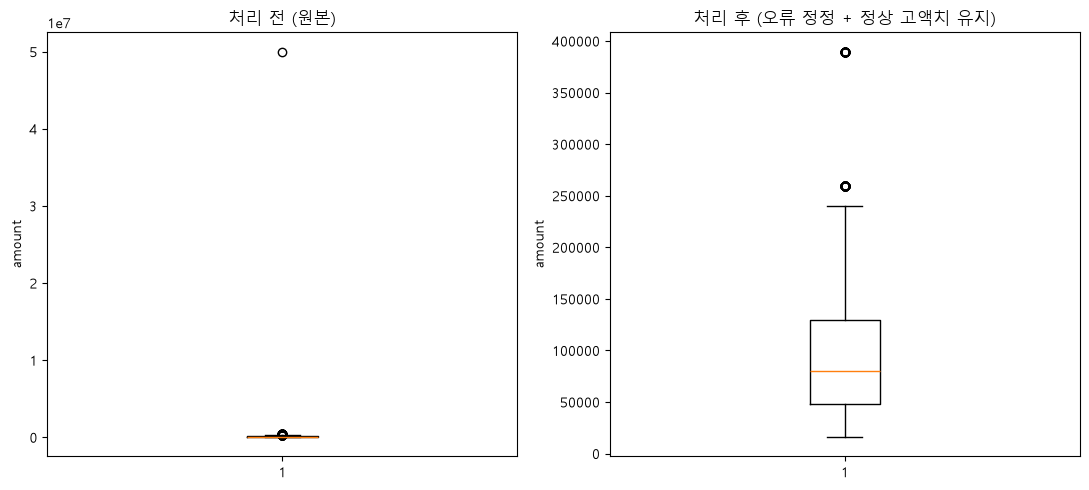

In [16]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 처리 전 — 원본 (50,000,000원 오류값 포함, 결측 있음)
axes[0].boxplot(partner["amount"].dropna())
axes[0].set_title("처리 전 (원본)")
axes[0].set_ylabel("amount")

# 처리 후 — 오류값(50,000,000) 정정 + 결측 복원, 정상 고액거래(플래그)는 유지
axes[1].boxplot(partner_clean["amount"])
axes[1].set_title("처리 후 (오류 정정 + 정상 고액치 유지)")
axes[1].set_ylabel("amount")

plt.tight_layout()
plt.show()

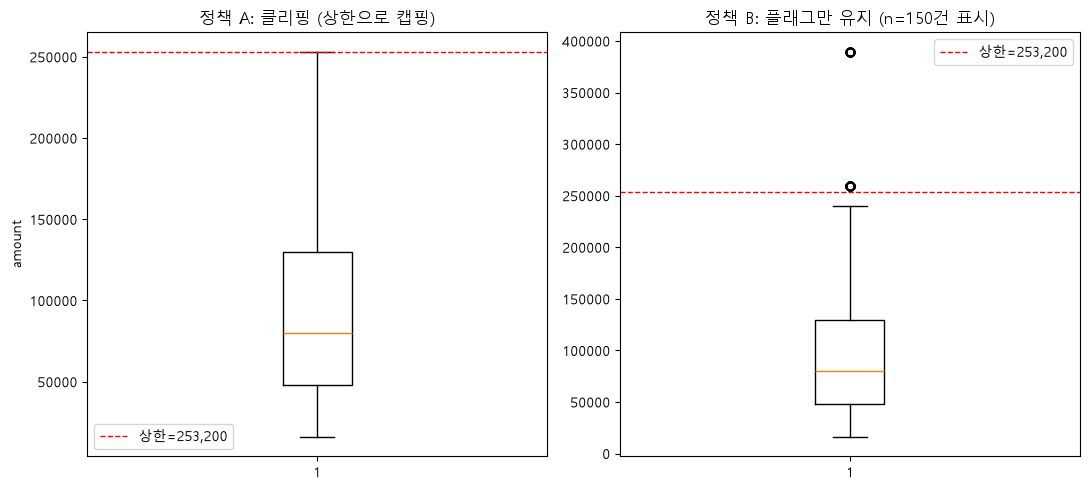

In [17]:
partner_policy = partner_clean.copy()

# 상한 계산 (정정된 amount 기준)
q1 = partner_policy["amount"].quantile(0.25)
q3 = partner_policy["amount"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

# 정책 A: 클리핑(capping) — 상한 초과값을 상한값으로 눌러버림
amount_clipped = partner_policy["amount"].clip(upper=upper)

# 정책 B: 플래그만 — 값은 원본 그대로, amount_outlier 컬럼으로만 표시
amount_flagged = partner_policy["amount"]  # 값 자체는 변경 없음

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].boxplot(amount_clipped)
axes[0].axhline(upper, color="red", linestyle="--", linewidth=1, label=f"상한={upper:,.0f}")
axes[0].set_title("정책 A: 클리핑 (상한으로 캡핑)")
axes[0].set_ylabel("amount")
axes[0].legend()

axes[1].boxplot(amount_flagged)
axes[1].axhline(upper, color="red", linestyle="--", linewidth=1, label=f"상한={upper:,.0f}")
axes[1].set_title(f"정책 B: 플래그만 유지 (n={partner_policy['amount_outlier'].sum()}건 표시)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# 코드 퀴즈 — 모범 답안
out = orders.copy()

# 1) quantity 이상치 → NaN
mask_q, _ = detect_outliers_iqr(out["quantity"])
out.loc[mask_q, "quantity"] = np.nan
# 결측 처리는 중앙값
out["quantity"] = out["quantity"].fillna(out["quantity"].median()).astype(int)

# 2) amount 결측 → 채널별 중앙값
out["amount"] = out["amount"].fillna(out.groupby("channel")["amount"].transform("median"))

# 3) 검증
print("quantity 결측:", out["quantity"].isnull().sum())
print("amount 결측:", out["amount"].isnull().sum())

quantity 결측: 0
amount 결측: 0


[*********************100%***********************]  3 of 3 completed

(4282, 9)
        Date     Adj Close    Close     High      Low     Open      Volume  \
0 2010-01-04  11842.955078  16180.0  16180.0  16000.0  16060.0  11950800.0   
1 2010-01-05  12033.263672  16440.0  16580.0  16300.0  16520.0  27925850.0   
2 2010-01-06  12311.403320  16820.0  16820.0  16520.0  16580.0  22948850.0   
3 2010-01-07  11901.513672  16260.0  16820.0  16260.0  16820.0  22107950.0   
4 2010-01-08  12018.625977  16420.0  16420.0  16120.0  16400.0  14777550.0   

   trading_value  daily_return  
0   1.933639e+11           NaN  
1   4.591010e+11      1.606922  
2   3.859997e+11      2.311436  
3   3.594753e+11     -3.329370  
4   2.426474e+11      0.984010  

[열별 결측]
               missing  missing_pct(%)
daily_return       380            8.87
Adj Close          219            5.11
High               219            5.11
Close              219            5.11
Low                219            5.11
Open               219            5.11
Volume             219            5.11
tr

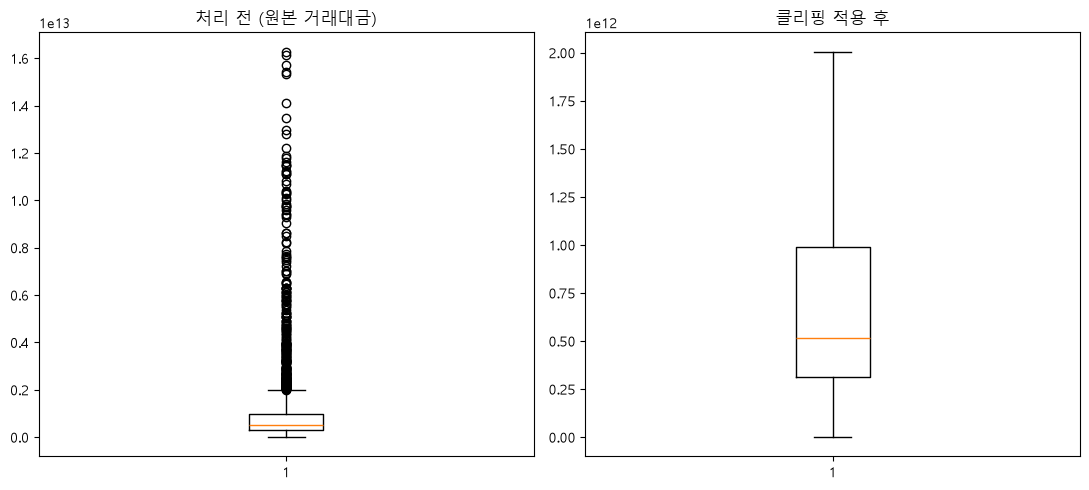

In [19]:
!pip install yfinance --upgrade --quiet
import pandas as pd
import numpy as np
from datetime import datetime
import yfinance as yf

start = datetime(2010, 1, 1)
end = datetime.today()

stk_tickers = ['005930.KS', 'IBM', 'GOOGL']
ccy_tickers = ['KRW=X', 'GBPUSD=X']
idx_tickers = ['^GSPC', '^DJI', '^VIX']

stk_data = yf.download(stk_tickers, start, end, auto_adjust=False)
new_columns = pd.MultiIndex.from_tuples(
    [(item[0], 'SMSG' if item[1] == '005930.KS' else item[1]) for item in stk_data.columns]
)
stk_data.columns = new_columns

# ========== 삼성전자만 뽑아서 지금까지 쓰던 형태(long format)로 변환 ==========
samsung = stk_data.xs('SMSG', axis=1, level=1).copy()
samsung = samsung.reset_index()  # Date를 컬럼으로
samsung["trading_value"] = samsung["Close"] * samsung["Volume"]   # amount와 동일한 개념
samsung["daily_return"] = samsung["Close"].pct_change() * 100     # return_amount와 동일한 개념

print(samsung.shape)
print(samsung.head())

# ========== 1. 결측 진단 (옷장패션과 동일 함수 재사용) ==========
def missing_summary(df):
    s = df.isnull().sum()
    p = (df.isnull().mean() * 100).round(2)
    out = pd.DataFrame({"missing": s, "missing_pct(%)": p})
    return out[out["missing"] > 0].sort_values("missing", ascending=False)

print("\n[열별 결측]")
print(missing_summary(samsung))

# ========== 2. IQR 이상치 탐지 (동일 함수 재사용) ==========
def detect_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper), (lower, upper)

num_cols = ["Open", "High", "Low", "Close", "Volume", "trading_value", "daily_return"]
print("\n[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(samsung[c].dropna())
    print(f"  {c:15s}  하한={lo:>15.2f}  상한={up:>15.2f}  이상치={mask.sum()}건")

# ========== 3. 클리핑 vs 플래그 정책 비교 (boxplot) ==========
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"

q1, q3 = samsung["trading_value"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
clipped = samsung["trading_value"].clip(upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].boxplot(samsung["trading_value"].dropna())
axes[0].set_title("처리 전 (원본 거래대금)")
axes[1].boxplot(clipped.dropna())
axes[1].set_title("클리핑 적용 후")
plt.tight_layout()
plt.show()

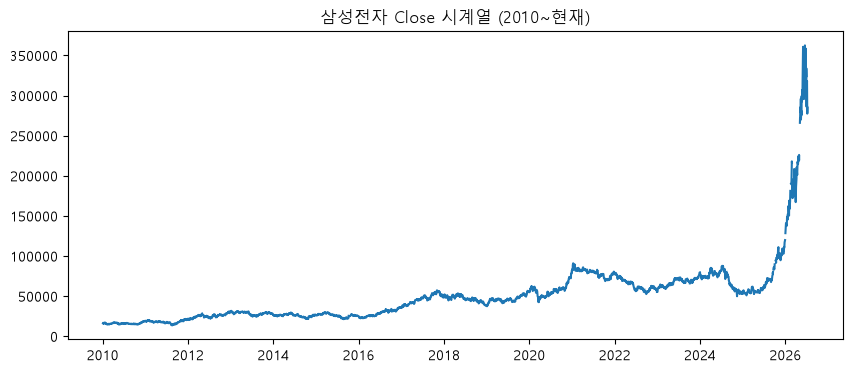

Date
2025      2
2026    128
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(samsung["Date"], samsung["Close"])
ax.set_title("삼성전자 Close 시계열 (2010~현재)")
plt.show()

# 이상치로 잡힌 날짜들이 특정 시기에 몰려있는지 확인
mask_close, (lo, up) = detect_outliers_iqr(samsung["Close"].dropna())
outlier_dates = samsung.loc[samsung["Close"].dropna().index][mask_close]["Date"]
print(outlier_dates.dt.year.value_counts().sort_index())

In [21]:
# 방법 1: 연도별/구간별로 나눠서 각 구간 안에서만 IQR 적용 (구간 내 상대적 이상치만 탐지)
samsung["year"] = samsung["Date"].dt.year
for year, group in samsung.groupby("year"):
    mask, (lo, up) = detect_outliers_iqr(group["Close"].dropna())
    if mask.sum() > 0:
        print(f"{year}: 이상치 {mask.sum()}건 (하한={lo:.0f}, 상한={up:.0f})")

# 방법 2: 가격 수준(level) 대신 수익률(return)로 보면 추세 문제가 대부분 사라짐
mask_r, (lo_r, up_r) = detect_outliers_iqr(samsung["daily_return"].dropna())
print(f"\ndaily_return 이상치: {mask_r.sum()}건 (하한={lo_r:.2f}%, 상한={up_r:.2f}%)")

2010: 이상치 16건 (하한=13800, 상한=18120)
2011: 이상치 2건 (하한=14058, 상한=21878)
2015: 이상치 6건 (하한=21740, 상한=30700)
2019: 이상치 1건 (하한=36481, 상한=56531)
2020: 이상치 16건 (하한=40538, 상한=71838)

daily_return 이상치: 153건 (하한=-4.00%, 상한=4.04%)


주식시장 데이터에 동일한 절차를 적용해보니, 결측과 이상치 모두 옷장패션과는 근본적으로 다른 원인을 가지고 있었다. 
결측 219건(5.11%)은 여러 거래소의 거래일을 합쳐 인덱스를 구성하는 과정에서 한국 시장 휴장일에 발생한 구조적 결측으로, 
이는 옷장패션의 amount 결측(앱 채널 버그로 인한 MAR)과 달리 통계적 대체가 아닌 단순 삭제가 맞는 처리였다. 
이상치는 더 근본적인 차이를 드러냈는데, Close 130건 중 128건이 2026년 한 해에 집중되어 있었다 
— 이는 개별 값의 오류가 아니라 최근 가격이 과거 16년의 박스권을 벗어난 새로운 구간으로 이동했기 때문이다. 
  즉 한 종목의 장기 시계열에 단일 IQR을 적용하면 '레벨이 달라진 시기 전체'가 통째로 이상치로 잡히는데, 
  이는 여러 독립적인 거래 건에서 반복적으로 나타나는 옷장패션의 고액거래 이상치와는 성격이 전혀 다르다. 
  결국 같은 IQR 기법이라도, 횡단면 데이터(여러 주문 건)에는 유효하지만 추세가 있는 시계열(한 종목의 장기 가격)에는 그대로 적용하면 안 되며, 
  구간별 IQR이나 수익률 기반 분석처럼 데이터의 시간적 구조를 고려한 방법이 필요하다는 걸 확인했다.